In [ ]:
# Implementing feed forward neural network on CIFAR DATASET

In [1]:
# import libraries 
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import matplotlib.pyplot as plt


In [2]:
# load data-set
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training Images:", x_train.shape)
print("Training Labels:", y_train.shape)

print("Testing Images:", x_test.shape)
print("Testing Labels:", y_test.shape)

C:\Users\sahil\anaconda3\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Training Images: (50000, 32, 32, 3)
Training Labels: (50000, 1)
Testing Images: (10000, 32, 32, 3)
Testing Labels: (10000, 1)


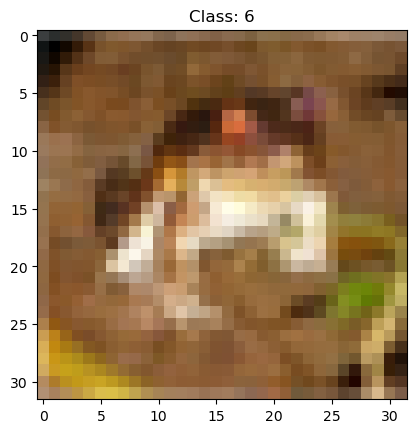

In [3]:
# display sample language 
plt.imshow(x_train[0])
plt.title(f"Class: {y_train[0][0]}")
plt.show()


In [4]:
#normalize image
x_train = x_train / 255.0
x_test = x_test / 255.0

In [5]:
#build feed forward neural network
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input

model = Sequential([
    Input(shape=(32, 32, 3)),
    Flatten(),

    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),

    Dense(10, activation='softmax')
])

In [6]:
#verify mode build correcttly 
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 3072)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       1,573,376 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
#compile model 
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
#train model
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step - accuracy: 0.3186 - loss: 1.8816 - val_accuracy: 0.3484 - val_loss: 1.8230
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 46ms/step - accuracy: 0.3986 - loss: 1.6820 - val_accuracy: 0.4064 - val_loss: 1.6450
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.4268 - loss: 1.5964 - val_accuracy: 0.4250 - val_loss: 1.6022
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 44ms/step - accuracy: 0.4483 - loss: 1.5423 - val_accuracy: 0.4308 - val_loss: 1.5716
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 46ms/step - accuracy: 0.4631 - loss: 1.5032 - val_accuracy: 0.4570 - val_loss: 1.5447
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 46ms/step - accuracy: 0.4771 - loss: 1.4696 - val_accuracy: 0.4760 - val_loss: 1.4867
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 36s 50ms/step - accuracy: 0.4861 - loss: 1.4387 - val_accuracy: 0.4722 - val_loss: 1.4905
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.4978 - loss: 1.4057 - 

In [9]:
#evalvate model 
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test
)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.4834 - loss: 1.4549
Test Accuracy: 0.48339998722076416


In [10]:
#predict on test data 
predictions = model.predict(x_test)

predicted_class = predictions[0].argmax()

print("Predicted Class:", predicted_class)
print("Actual Class:", y_test[0][0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
Predicted Class: 5
Actual Class: 3


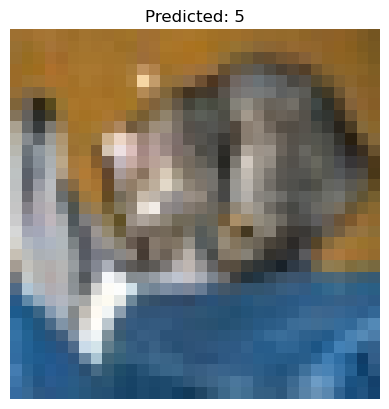

In [11]:
#visualize prediction
plt.imshow(x_test[0])
plt.title(f"Predicted: {predicted_class}")
plt.axis('off')
plt.show()

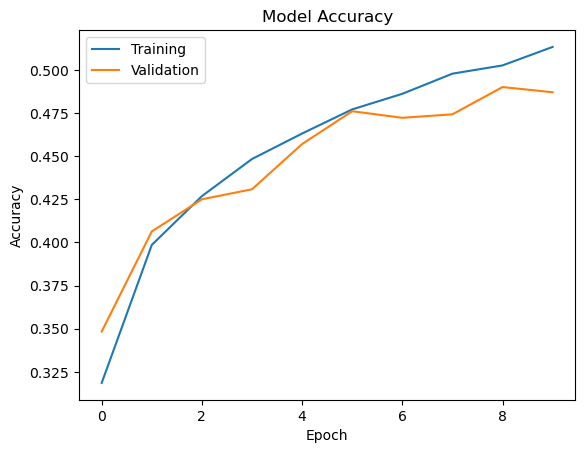

In [12]:
#plot accuracy graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Training', 'Validation'])
plt.show()